# CIFAR-10 with a Cauchy-Activated CNN

This notebook builds a full CNN in-place (no MLP from src) to classify CIFAR-10.
The model supports `activation_mode = "cauchy"` or `"relu"` for quick comparisons.

In [1]:
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
@dataclass
class Config:
    batch_size: int = 128
    epochs: int = 20
    lr: float = 1e-3
    weight_decay: float = 1e-4
    num_workers: int = 2
    base_channels: int = 64

cfg = Config()

experiment_grid = [
    ("standard", "relu"),
    ("standard", "cauchy"),
    ("cauchy", "relu"),
    ("cauchy", "cauchy"),
]

cfg

Config(batch_size=128, epochs=20, lr=0.001, weight_decay=0.0001, num_workers=2, base_channels=64)

In [3]:
import os

os.environ["HTTP_PROXY"] = "http://127.0.0.1:7890"
os.environ["HTTPS_PROXY"] = "http://127.0.0.1:7890"

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=(device.type == "cuda"),
)

classes = train_ds.classes
print(f"Train samples: {len(train_ds)}, Test samples: {len(test_ds)}")
print(classes)

/data1/linjiangtao2024/cauchy_activation/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples: 50000, Test samples: 10000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


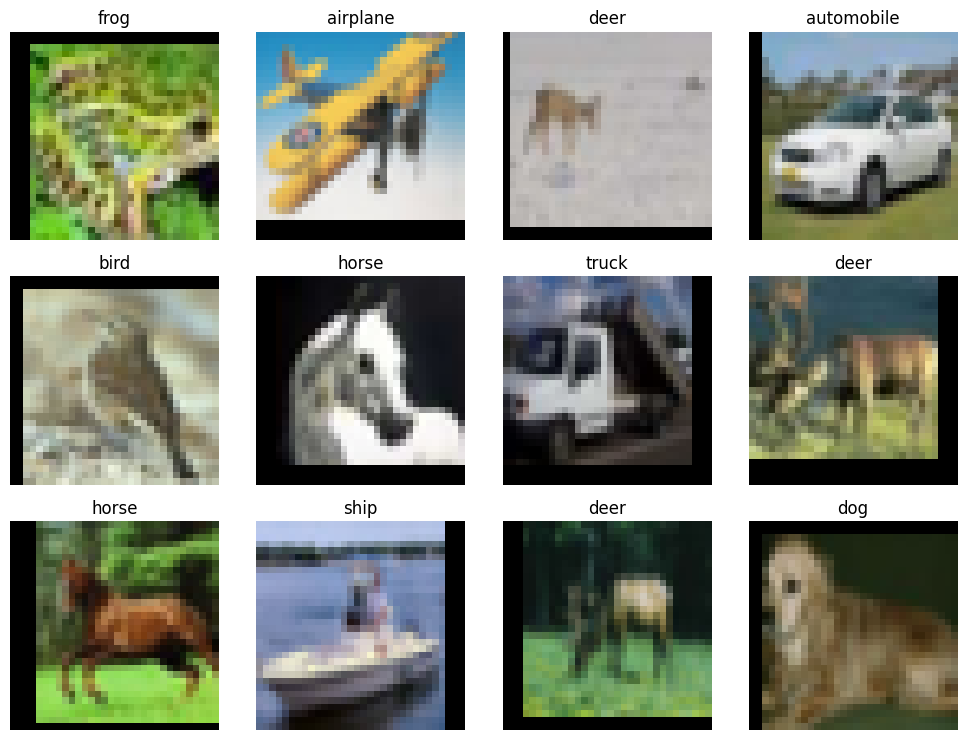

In [4]:
def show_batch(dl, class_names, n=12):
    xb, yb = next(iter(dl))
    xb = xb[:n]
    yb = yb[:n]

    xb = xb * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
    xb = xb.clamp(0, 1)

    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(10, 2.5 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(np.transpose(xb[i].numpy(), (1, 2, 0)))
        plt.title(class_names[int(yb[i])])
        plt.axis("off")
    plt.tight_layout()

show_batch(train_loader, classes, n=12)

In [5]:
class CauchyActivation(nn.Module):
    def __init__(self, lambda1=1.0, lambda2=0.0, d=1.0):
        super().__init__()
        self.lambda1 = nn.Parameter(torch.tensor(float(lambda1)))
        self.lambda2 = nn.Parameter(torch.tensor(float(lambda2)))
        self.raw_d = nn.Parameter(torch.tensor(float(d)))

    def forward(self, x):
        d = F.softplus(self.raw_d) + 1e-6
        denom = x.pow(2) + d.pow(2)
        return self.lambda1 * x / denom + self.lambda2 / denom


def get_activation(mode):
    if mode == "cauchy":
        return CauchyActivation()
    if mode == "relu":
        return nn.ReLU(inplace=True)
    raise ValueError("activation_mode must be 'cauchy' or 'relu'")


class ConvTransformBlock(nn.Module):
    def __init__(self, channels, activation_mode="cauchy", dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.act1 = get_activation(activation_mode)

        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        h = self.conv1(x)
        h = self.bn1(h)
        h = self.act1(h)

        h = self.conv2(h)
        h = self.bn2(h)
        h = self.dropout(h)
        return h


class ResidualStage(nn.Module):
    def __init__(self, channels, num_blocks, activation_mode="cauchy", residual_mode="standard", dropout=0.0):
        super().__init__()
        if residual_mode not in {"standard", "cauchy"}:
            raise ValueError("residual_mode must be 'standard' or 'cauchy'")

        self.residual_mode = residual_mode
        self.blocks = nn.ModuleList(
            [ConvTransformBlock(channels, activation_mode=activation_mode, dropout=dropout) for _ in range(num_blocks)]
        )
        self.post_act = get_activation(activation_mode)

        self.mix_raw_lambda = nn.Parameter(torch.zeros(num_blocks + 1))
        self.mix_raw_d = nn.Parameter(torch.ones(num_blocks + 1))

    def _cauchy_mix(self, history, target_layer):
        lam = F.softplus(self.mix_raw_lambda[target_layer]) + 1e-6
        d = F.softplus(self.mix_raw_d[target_layer]) + 1e-6
        count = len(history)

        distances = torch.arange(
            target_layer, target_layer - count, -1, device=history[0].device
        ).float()
        weights = lam / (distances.pow(2) + d.pow(2))
        weights = weights / (weights.sum() + 1e-8)

        stacked = torch.stack(history, dim=0)
        return (weights[:, None, None, None, None] * stacked).sum(dim=0)

    def forward(self, x):
        h = x
        history = [h]

        for layer_idx, block in enumerate(self.blocks, start=1):
            transformed = block(h)
            if self.residual_mode == "standard":
                h = h + transformed
            else:
                h = transformed + self._cauchy_mix(history, layer_idx)
            h = self.post_act(h)
            history.append(h)

        return h


class CauchyCNN(nn.Module):
    def __init__(self, num_classes=10, base_channels=64, activation_mode="cauchy", residual_mode="standard"):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            get_activation(activation_mode),
        )

        self.stage1 = nn.Sequential(
            ResidualStage(
                base_channels,
                num_blocks=2,
                activation_mode=activation_mode,
                residual_mode=residual_mode,
                dropout=0.05,
            ),
            nn.MaxPool2d(2),
        )

        c2 = base_channels * 2
        self.down1 = nn.Sequential(
            nn.Conv2d(base_channels, c2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c2),
            get_activation(activation_mode),
        )
        self.stage2 = nn.Sequential(
            ResidualStage(
                c2,
                num_blocks=2,
                activation_mode=activation_mode,
                residual_mode=residual_mode,
                dropout=0.1,
            ),
            nn.MaxPool2d(2),
        )

        c3 = c2 * 2
        self.down2 = nn.Sequential(
            nn.Conv2d(c2, c3, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c3),
            get_activation(activation_mode),
        )
        self.stage3 = ResidualStage(
            c3,
            num_blocks=2,
            activation_mode=activation_mode,
            residual_mode=residual_mode,
            dropout=0.1,
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(c3, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.down1(x)
        x = self.stage2(x)
        x = self.down2(x)
        x = self.stage3(x)
        x = self.head(x)
        return x


preview_model = CauchyCNN(
    num_classes=10,
    base_channels=cfg.base_channels,
    activation_mode="cauchy",
    residual_mode="cauchy",
).to(device)
num_params = sum(p.numel() for p in preview_model.parameters() if p.requires_grad)
print(preview_model.__class__.__name__)
print(f"Trainable params: {num_params:,}")

CauchyCNN
Trainable params: 3,474,048


In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())
        total_count += xb.size(0)

    return total_loss / total_count, total_correct / total_count


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += float(loss.item()) * xb.size(0)
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())
        total_count += xb.size(0)

    return total_loss / total_count, total_correct / total_count

In [7]:
from tqdm import tqdm


def extract_cauchy_params(model):
    """
    Extract lambda and d parameters from all ResidualStage modules in the model.
    Returns a dict with stage names as keys and param values as values.
    """
    params = {}
    for name, module in model.named_modules():
        if isinstance(module, ResidualStage):
            with torch.no_grad():
                lam = F.softplus(module.mix_raw_lambda).cpu().numpy()
                d = F.softplus(module.mix_raw_d).cpu().numpy()
            params[name] = {"lambda": lam, "d": d}
    return params


def run_experiment(residual_mode, activation_mode, cfg):
    model = CauchyCNN(
        num_classes=10,
        base_channels=cfg.base_channels,
        activation_mode=activation_mode,
        residual_mode=residual_mode,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": [], "cauchy_params": []}

    pbar = tqdm(
        range(cfg.epochs), desc=f"Experiment: {residual_mode} + {activation_mode}"
    )

    for epoch in pbar:
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if residual_mode == "cauchy":
            params = extract_cauchy_params(model)
            history["cauchy_params"].append(params)
        else:
            history["cauchy_params"].append(None)

        pbar.set_postfix(
            {
                "train_loss": f"{train_loss:.4f}",
                "train_acc": f"{train_acc:.4f}",
                "test_loss": f"{test_loss:.4f}",
                "test_acc": f"{test_acc:.4f}",
            }
        )

    return model, history


results = {}
best_key = None
best_acc = -1.0
best_model_state = None

for residual_mode, activation_mode in experiment_grid:
    exp_key = f"{residual_mode}_{activation_mode}"
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_key}")
    model, history = run_experiment(residual_mode, activation_mode, cfg)
    final_acc = history["test_acc"][-1]
    results[exp_key] = {
        "residual_mode": residual_mode,
        "activation_mode": activation_mode,
        "history": history,
        "final_test_acc": final_acc,
    }

    if final_acc > best_acc:
        best_acc = final_acc
        best_key = exp_key
        best_model_state = {
            k: v.detach().cpu().clone() for k, v in model.state_dict().items()
        }

print("\n" + "=" * 80)
print(f"Best setting: {best_key}, final test acc={best_acc:.4f}")


Running experiment: standard_relu


Experiment: standard + relu: 100%|██████████| 20/20 [04:35<00:00, 13.78s/it, train_loss=0.1233, train_acc=0.9586, test_loss=0.2920, test_acc=0.9108]



Running experiment: standard_cauchy


Experiment: standard + cauchy: 100%|██████████| 20/20 [07:18<00:00, 21.93s/it, train_loss=0.2671, train_acc=0.9067, test_loss=0.4563, test_acc=0.8524]



Running experiment: cauchy_relu


Experiment: cauchy + relu: 100%|██████████| 20/20 [05:27<00:00, 16.38s/it, train_loss=0.1170, train_acc=0.9602, test_loss=0.2983, test_acc=0.9102]



Running experiment: cauchy_cauchy


Experiment: cauchy + cauchy: 100%|██████████| 20/20 [08:19<00:00, 24.96s/it, train_loss=0.1814, train_acc=0.9373, test_loss=0.4183, test_acc=0.8759]


Best setting: standard_relu, final test acc=0.9108


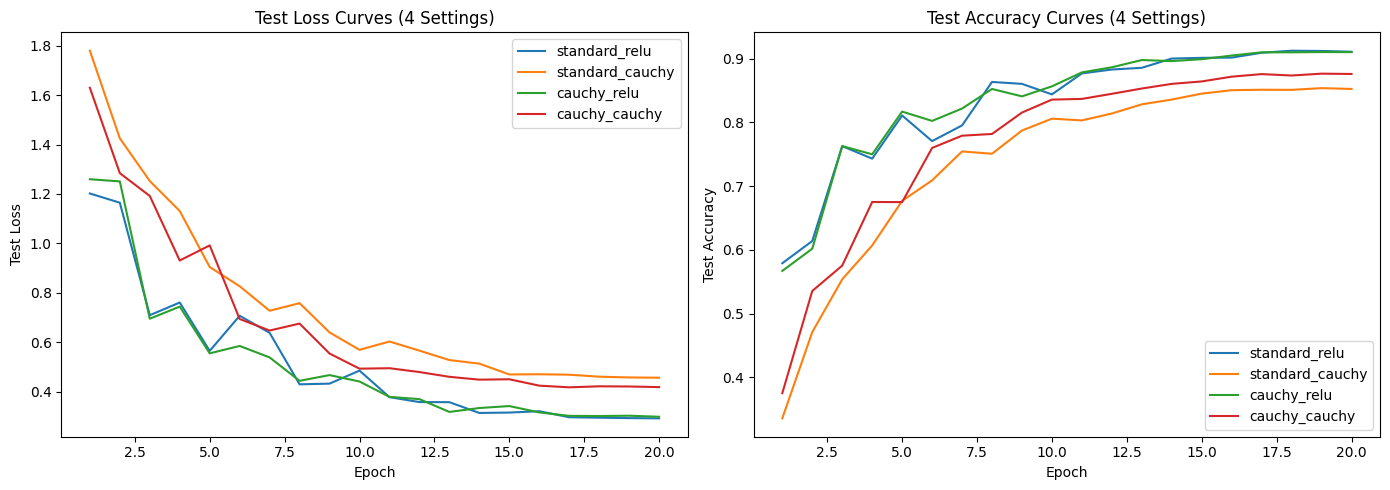

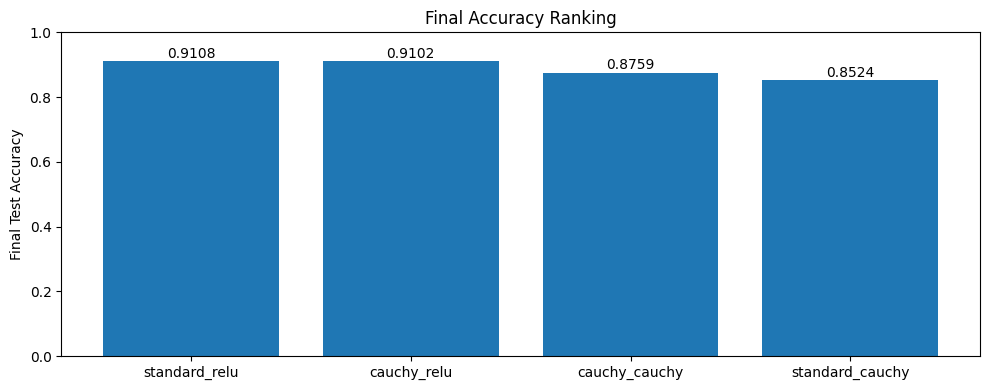

In [8]:
epochs_axis = np.arange(1, cfg.epochs + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
for exp_key, payload in results.items():
    plt.plot(epochs_axis, payload["history"]["test_loss"], label=exp_key)
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss Curves (4 Settings)")
plt.legend()

plt.subplot(1, 2, 2)
for exp_key, payload in results.items():
    plt.plot(epochs_axis, payload["history"]["test_acc"], label=exp_key)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Curves (4 Settings)")
plt.legend()
plt.tight_layout()

ranked = sorted(results.items(), key=lambda kv: kv[1]["final_test_acc"], reverse=True)
labels = [k for k, _ in ranked]
vals = [v["final_test_acc"] for _, v in ranked]

plt.figure(figsize=(10, 4))
plt.bar(labels, vals)
plt.ylim(0, 1.0)
plt.ylabel("Final Test Accuracy")
plt.title("Final Accuracy Ranking")
for i, v in enumerate(vals):
    plt.text(i, v + 0.01, f"{v:.4f}", ha="center")
plt.tight_layout()

In [9]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_targets.append(yb)
    return torch.cat(all_preds), torch.cat(all_targets)

best_residual, best_activation = best_key.split("_", 1)
best_model = CauchyCNN(
    num_classes=10,
    base_channels=cfg.base_channels,
    activation_mode=best_activation,
    residual_mode=best_residual,
).to(device)
best_model.load_state_dict(best_model_state)

preds, targets = collect_predictions(best_model, test_loader, device)
overall_acc = (preds == targets).float().mean().item()
print(f"Best setting: {best_key}")
print(f"Final Test Accuracy (best model): {overall_acc:.4f}")

num_classes = len(classes)
cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
for t, p in zip(targets, preds):
    cm[int(t), int(p)] += 1

per_class_acc = cm.diag().float() / cm.sum(dim=1).clamp(min=1).float()
for i, name in enumerate(classes):
    print(f"{name:>10s}: {per_class_acc[i].item():.4f}")

Best setting: standard_relu
Final Test Accuracy (best model): 0.9108
  airplane: 0.9260
automobile: 0.9650
      bird: 0.8840
       cat: 0.8030
      deer: 0.9090
       dog: 0.8510
      frog: 0.9400
     horse: 0.9370
      ship: 0.9550
     truck: 0.9380


In [10]:
# Optional: save best-model checkpoint plus all experiment metrics
ckpt_path = "./cauchy_cnn_cifar10_ablation.pt"
torch.save(
    {
        "best_key": best_key,
        "best_model_state_dict": best_model_state,
        "results": results,
        "config": cfg.__dict__,
        "classes": classes,
        "experiment_grid": experiment_grid,
    },
    ckpt_path,
)
print(f"Saved checkpoint to {ckpt_path}")

Saved checkpoint to ./cauchy_cnn_cifar10_ablation.pt


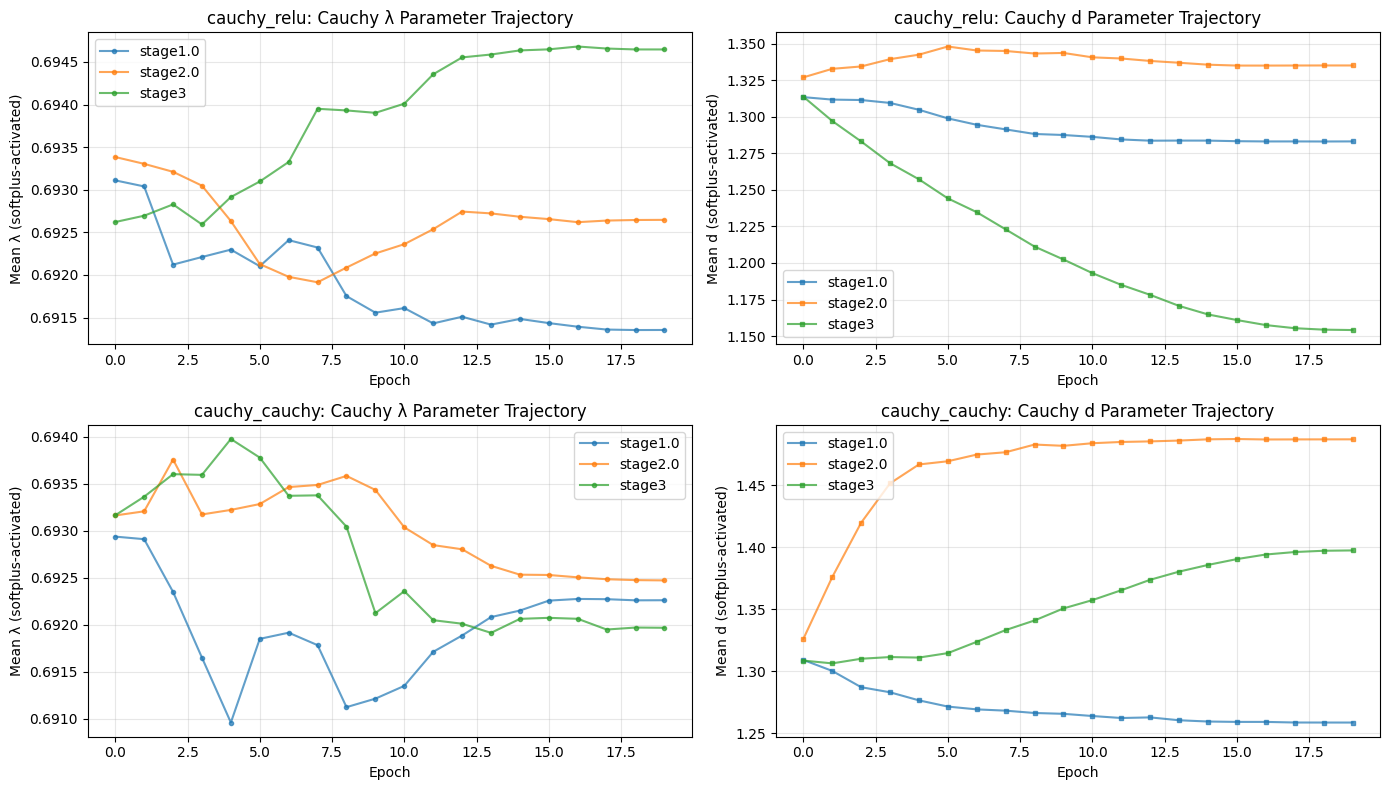

In [11]:
# Visualize Cauchy parameter trajectories across training

cauchy_experiments = [k for k in results.keys() if results[k]["residual_mode"] == "cauchy"]

if cauchy_experiments:
    fig, axes = plt.subplots(len(cauchy_experiments), 2, figsize=(14, 4 * len(cauchy_experiments)))
    if len(cauchy_experiments) == 1:
        axes = axes.reshape(1, -1)

    for idx, exp_key in enumerate(cauchy_experiments):
        history = results[exp_key]["history"]
        params_list = history["cauchy_params"]

        ax_lambda = axes[idx, 0]
        ax_d = axes[idx, 1]

        stage_names = [name for name in params_list[0].keys() if params_list[0][name] is not None]

        for stage_name in stage_names:
            lambda_vals = []
            d_vals = []
            for epoch_params in params_list:
                if epoch_params and stage_name in epoch_params:
                    lambda_vals.append(epoch_params[stage_name]["lambda"].mean())
                    d_vals.append(epoch_params[stage_name]["d"].mean())

            epochs_range = np.arange(len(lambda_vals))
            ax_lambda.plot(epochs_range, lambda_vals, label=stage_name, marker="o", markersize=3, alpha=0.7)
            ax_d.plot(epochs_range, d_vals, label=stage_name, marker="s", markersize=3, alpha=0.7)

        ax_lambda.set_xlabel("Epoch")
        ax_lambda.set_ylabel("Mean λ (softplus-activated)")
        ax_lambda.set_title(f"{exp_key}: Cauchy λ Parameter Trajectory")
        ax_lambda.legend()
        ax_lambda.grid(alpha=0.3)

        ax_d.set_xlabel("Epoch")
        ax_d.set_ylabel("Mean d (softplus-activated)")
        ax_d.set_title(f"{exp_key}: Cauchy d Parameter Trajectory")
        ax_d.legend()
        ax_d.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No Cauchy residual experiments found in results.")

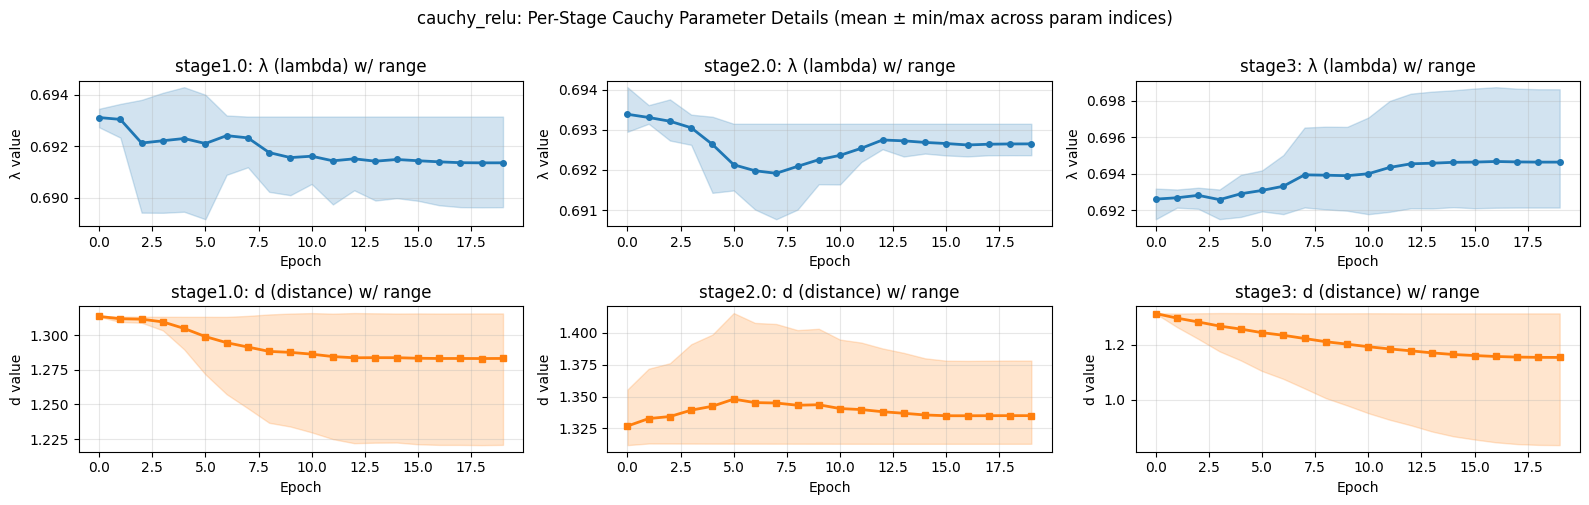

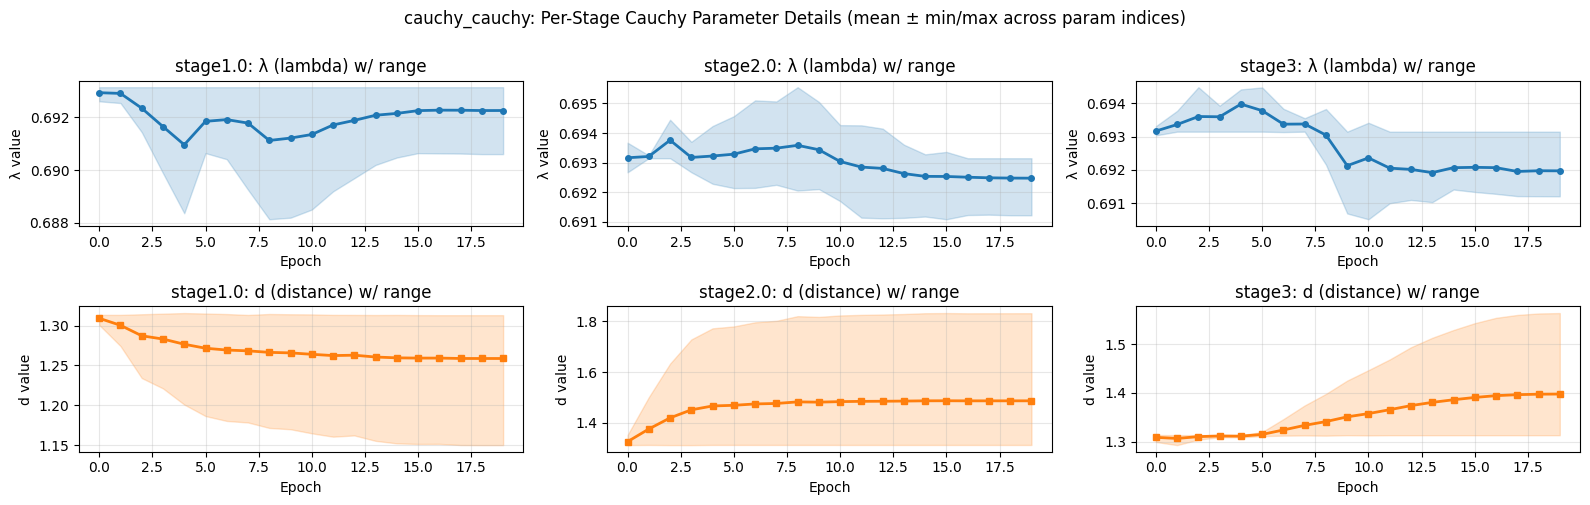

In [12]:
# Detailed analysis: Cauchy param evolution vs test accuracy for each stage

for exp_key in cauchy_experiments:
    history = results[exp_key]["history"]
    params_list = history["cauchy_params"]
    test_acc = history["test_acc"]

    stage_names = list(params_list[0].keys()) if params_list[0] else []

    if not stage_names:
        continue

    fig = plt.figure(figsize=(16, 5))
    num_stages = len(stage_names)

    for s_idx, stage_name in enumerate(stage_names):
        ax = plt.subplot(2, num_stages, s_idx + 1)

        lambda_vals = []
        d_vals = []
        for epoch_params in params_list:
            if epoch_params and stage_name in epoch_params:
                lambda_vals.append(epoch_params[stage_name]["lambda"])
                d_vals.append(epoch_params[stage_name]["d"])

        lambda_array = np.array(lambda_vals)
        d_array = np.array(d_vals)

        epochs_range = np.arange(len(lambda_vals))
        ax.plot(epochs_range, lambda_array.mean(axis=1), "o-", linewidth=2, markersize=4, label="λ mean", color="C0")
        ax.fill_between(epochs_range, lambda_array.min(axis=1), lambda_array.max(axis=1), alpha=0.2, color="C0")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("λ value")
        ax.set_title(f"{stage_name}: λ (lambda) w/ range")
        ax.grid(alpha=0.3)

        ax_bottom = plt.subplot(2, num_stages, num_stages + s_idx + 1)
        ax_bottom.plot(epochs_range, d_array.mean(axis=1), "s-", linewidth=2, markersize=4, label="d mean", color="C1")
        ax_bottom.fill_between(epochs_range, d_array.min(axis=1), d_array.max(axis=1), alpha=0.2, color="C1")
        ax_bottom.set_xlabel("Epoch")
        ax_bottom.set_ylabel("d value")
        ax_bottom.set_title(f"{stage_name}: d (distance) w/ range")
        ax_bottom.grid(alpha=0.3)

    plt.suptitle(f"{exp_key}: Per-Stage Cauchy Parameter Details (mean ± min/max across param indices)", fontsize=12, y=1.00)
    plt.tight_layout()
    plt.show()

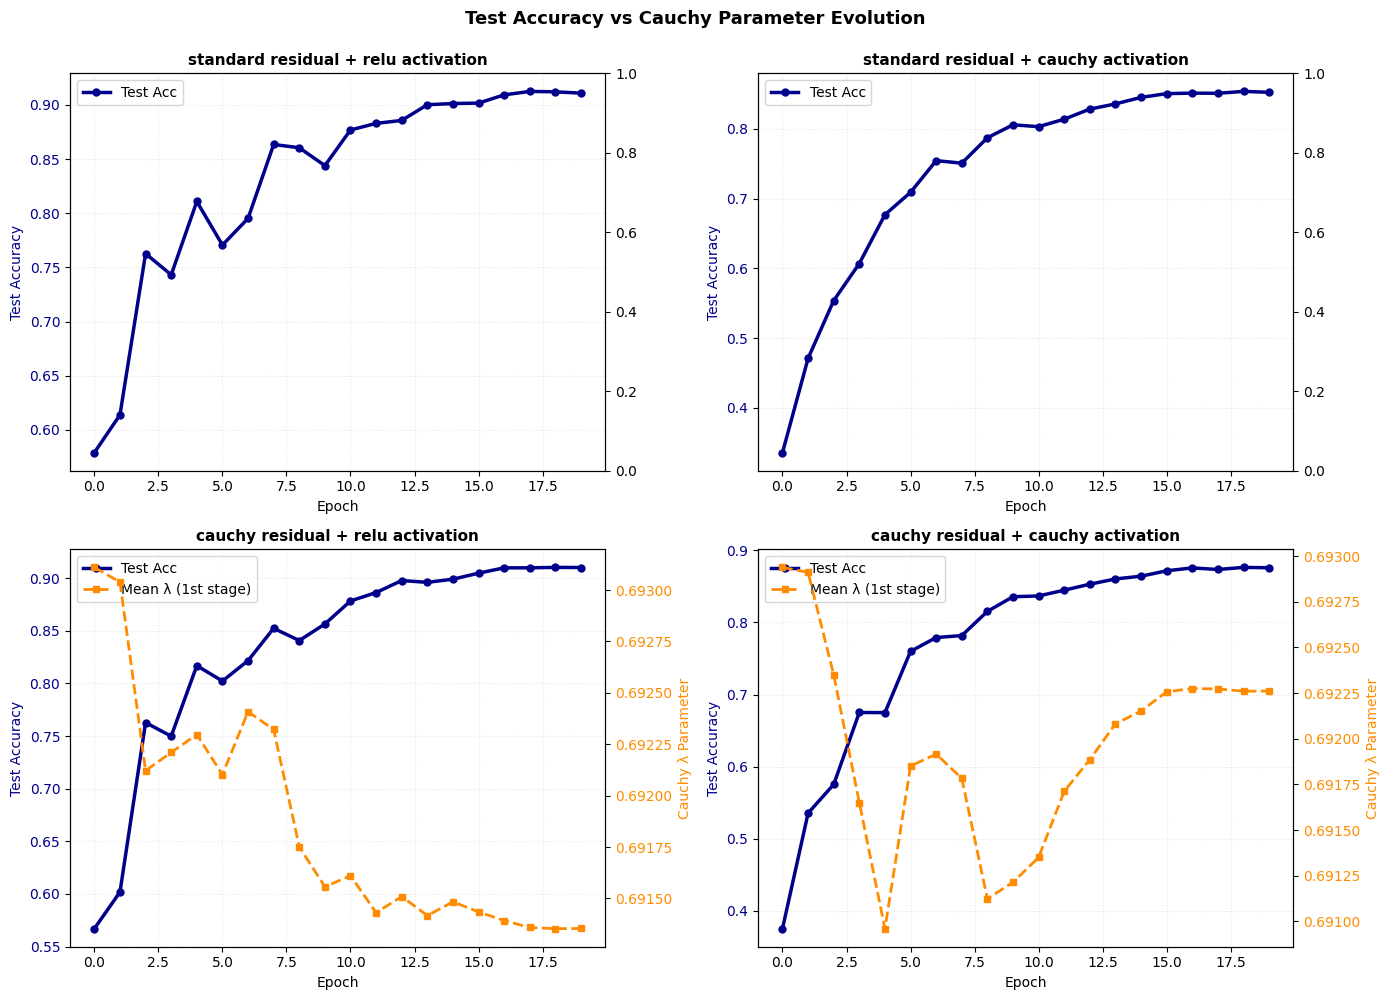

In [13]:
# Summary: Compare Cauchy learning with test accuracy convergence

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, exp_key in enumerate(results.keys()):
    if idx >= 4:
        break
    row, col = idx // 2, idx % 2
    ax = axes[row, col]

    test_acc = results[exp_key]["history"]["test_acc"]
    residual_mode = results[exp_key]["residual_mode"]
    activation_mode = results[exp_key]["activation_mode"]

    ax2 = ax.twinx()

    epochs_range = np.arange(len(test_acc))
    line1 = ax.plot(epochs_range, test_acc, "o-", linewidth=2.5, markersize=5, label="Test Acc", color="darkblue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Test Accuracy", color="darkblue")
    ax.tick_params(axis="y", labelcolor="darkblue")

    if residual_mode == "cauchy":
        params_list = results[exp_key]["history"]["cauchy_params"]
        if params_list and params_list[0]:
            stage_names = list(params_list[0].keys())
            if stage_names:
                stage_name = stage_names[0]
                lambda_vals = [p[stage_name]["lambda"].mean() if p and stage_name in p else np.nan for p in params_list]
                line2 = ax2.plot(epochs_range, lambda_vals, "s--", linewidth=2, markersize=4, label="Mean λ (1st stage)", color="darkorange")
                ax2.set_ylabel("Cauchy λ Parameter", color="darkorange")
                ax2.tick_params(axis="y", labelcolor="darkorange")
                lines = line1 + line2
                labels = [l.get_label() for l in lines]
            else:
                lines = line1
                labels = [l.get_label() for l in lines]
        else:
            lines = line1
            labels = [l.get_label() for l in lines]
    else:
        lines = line1
        labels = [l.get_label() for l in lines]

    ax.set_title(f"{residual_mode} residual + {activation_mode} activation", fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3, linestyle=":")
    ax.legend(lines, labels, loc="upper left")

plt.suptitle("Test Accuracy vs Cauchy Parameter Evolution", fontsize=13, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()